# The GPU Memory Equation: Where Every Byte Goes

**Workshop Section 1** (20 min) | LLM Inference at Scale

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/harshuljain13/llm-inference-at-scale/blob/master/workshop/01_memory_equation.ipynb)

**Goal:** Derive model memory from 3 anchor values, understand KV cache growth, and calculate how many users fit on your GPU.

Repo: [github.com/harshuljain13/llm-inference-at-scale](https://github.com/harshuljain13/llm-inference-at-scale)

In [1]:
!pip install -q transformers matplotlib

## The Three Anchor Values

Every transformer's memory footprint is determined by just three numbers:

| Symbol | Meaning | Llama 3.1 8B |
|--------|---------|-------------|
| **d** | Hidden dimension | 4096 |
| **L** | Number of layers | 32 |
| **P** | Total parameters | 8.03B |

From these, we derive everything: weight memory, KV cache per token, and max concurrent users.

In [2]:
from transformers import AutoConfig

config = AutoConfig.from_pretrained('meta-llama/Llama-3.1-8B')

d = config.hidden_size
L = config.num_hidden_layers
n_heads = config.num_attention_heads
n_kv_heads = config.num_key_value_heads
head_dim = d // n_heads
intermediate = config.intermediate_size

print(f'Hidden dim (d): {d}')
print(f'Layers (L): {L}')
print(f'Attention heads: {n_heads}, KV heads: {n_kv_heads}')
print(f'Head dim: {head_dim}')
print(f'MLP intermediate: {intermediate}')

Hidden dim (d): 4096
Layers (L): 32
Attention heads: 32, KV heads: 8
Head dim: 128
MLP intermediate: 14336


## Deriving Model Size

In FP16 (2 bytes per parameter):

$$\text{Model Memory} = P \times 2 \text{ bytes}$$

For 8.03B params: **~16.06 GB** just for weights.

But where do those parameters live? Let's break it down layer by layer.

In [3]:
bytes_per_param = 2  # FP16

# Per-layer attention: Q, K, V, O projections
attn_params = 4 * d * (n_kv_heads * head_dim) + 4 * d * d  # simplified
# Correct: Q = d*d, K = d*kv_d, V = d*kv_d, O = d*d
kv_d = n_kv_heads * head_dim
attn_params = d*d + d*kv_d + d*kv_d + d*d  # Q + K + V + O
attn_bytes = attn_params * bytes_per_param

# Per-layer MLP: gate, up, down (Llama uses SwiGLU: 3 matrices)
mlp_params = 3 * d * intermediate
mlp_bytes = mlp_params * bytes_per_param

# Total
layer_bytes = attn_bytes + mlp_bytes
total_bytes = layer_bytes * L

print(f'Per layer attention: {attn_bytes/1e6:.1f} MB ({attn_params/1e6:.1f}M params)')
print(f'Per layer MLP:       {mlp_bytes/1e6:.1f} MB ({mlp_params/1e6:.1f}M params)')
print(f'Per layer total:     {layer_bytes/1e6:.1f} MB')
print(f'All {L} layers:      {total_bytes/1e9:.2f} GB')
print(f'\n+ Embeddings & LM head: ~{(8.03e9*2 - total_bytes)/1e9:.2f} GB')
print(f'= Total model memory:  ~{8.03e9*2/1e9:.1f} GB (FP16)')

Per layer attention: 83.9 MB (41.9M params)
Per layer MLP:       352.3 MB (176.2M params)
Per layer total:     436.2 MB
All 32 layers:      13.96 GB

+ Embeddings & LM head: ~2.10 GB
= Total model memory:  ~16.1 GB (FP16)


## KV Cache: The Variable Cost

Each token stored in KV cache costs:

$$\text{KV per token} = 2 \times L \times n_{kv} \times d_h \times 2 \text{ bytes}$$

- Factor of 2: one K vector + one V vector
- $n_{kv}$: number of KV heads (8 for GQA in Llama 3.1)
- $d_h$: head dimension (128)
- Final 2: FP16 bytes

For Llama 3.1 8B: $2 \times 32 \times 8 \times 128 \times 2 = $ **128 KB per token**

This is the cost that scales with context length AND concurrent users.

KV cache per token: 128 KB


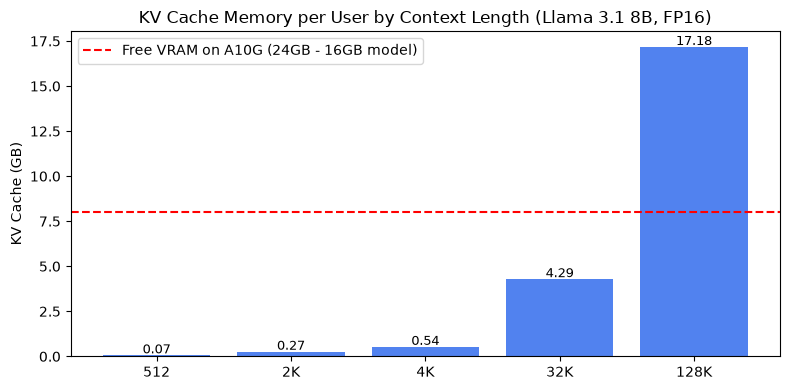

In [4]:
import matplotlib.pyplot as plt

kv_per_token = 2 * L * n_kv_heads * head_dim * bytes_per_param
print(f'KV cache per token: {kv_per_token/1024:.0f} KB')

ctx_lengths = [512, 2048, 4096, 32768, 131072]
kv_gb = [kv_per_token * s / 1e9 for s in ctx_lengths]

plt.figure(figsize=(8, 4))
bars = plt.bar([f'{s//1024}K' if s >= 1024 else str(s) for s in ctx_lengths], kv_gb, color='#2563eb', alpha=0.8)
plt.ylabel('KV Cache (GB)')
plt.title('KV Cache Memory per User by Context Length (Llama 3.1 8B, FP16)')
plt.axhline(y=24-16, color='red', linestyle='--', label='Free VRAM on A10G (24GB - 16GB model)')
plt.legend()
for bar, val in zip(bars, kv_gb):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## How Many Users Fit?

$$\text{Max Users} = \frac{\text{GPU VRAM} - \text{Model Weights}}{\text{KV per token} \times \text{context length}}$$

This is the fundamental capacity equation. Weights are fixed cost; KV cache is variable cost per user.

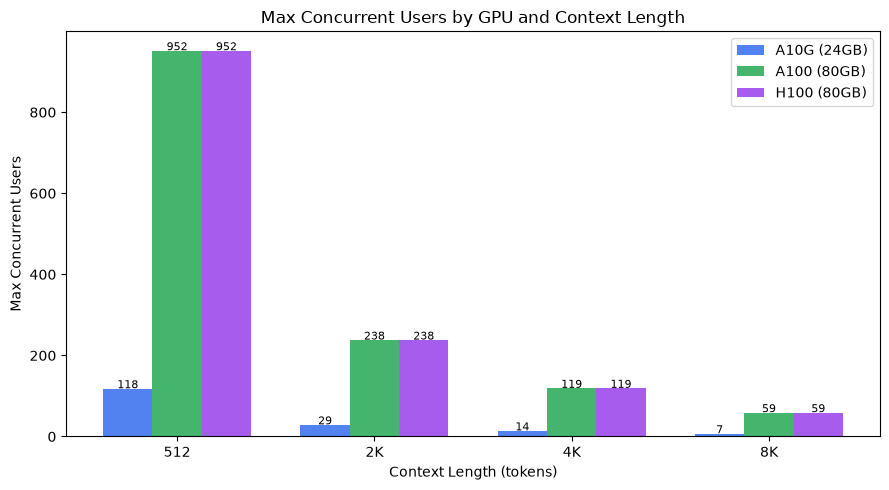

In [5]:
gpus = {'A10G (24GB)': 24e9, 'A100 (80GB)': 80e9, 'H100 (80GB)': 80e9}
model_bytes = 16.06e9
ctx_lens = [512, 2048, 4096, 8192]

fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(ctx_lens))
width = 0.25
colors = ['#2563eb', '#16a34a', '#9333ea']

for i, (gpu_name, vram) in enumerate(gpus.items()):
    free = vram - model_bytes
    users = [int(free / (kv_per_token * cl)) for cl in ctx_lens]
    bars = ax.bar([xi + i*width for xi in x], users, width, label=gpu_name, color=colors[i], alpha=0.8)
    for bar, val in zip(bars, users):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val), ha='center', fontsize=8)

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels([f'{cl//1024}K' if cl >= 1024 else str(cl) for cl in ctx_lens])
ax.set_xlabel('Context Length (tokens)')
ax.set_ylabel('Max Concurrent Users')
ax.set_title('Max Concurrent Users by GPU and Context Length')
ax.legend()
plt.tight_layout()
plt.show()

## Exercise: Your Model

Change the config above to explore:

1. **Llama 3.1 70B** (`meta-llama/Llama-3.1-70B`) -- how does GQA help at this scale?
2. **Mistral 7B** (`mistralai/Mistral-7B-v0.1`) -- compare KV cache with sliding window attention
3. **Your production model** -- what context length can you afford?

Key questions to answer:
- At what context length does KV cache exceed model weights?
- How does quantization (FP8 = 1 byte) change the picture?

## Key Takeaway

| Component | Type | Scales With |
|-----------|------|-------------|
| Model weights | **Fixed** | Parameters |
| KV cache | **Variable** | Users x Context Length |

**Weights determine which GPU you need. KV cache determines how many users you can serve.**

This is why every optimization in the next sections (quantization, GQA, paged attention, prefix caching) targets either reducing the fixed cost or compressing the variable cost.

---
*Next: Section 2 -- Why Is Decode So Slow? (The Roofline Model)*